# Natural language processing

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

## Task 1

In [3]:
toxic = pd.read_csv('../datasets/DS_09/toxic/toxic.csv', index_col='id')

In [4]:
labels_count = toxic.iloc[:,1:].sum()

In [5]:
not_tag = len(toxic[toxic.iloc[:,1:].sum(axis=1) == 0])

In [6]:
labels_count = labels_count.reset_index()
labels_count.columns = ['Категории', 'Количество комменатриев']
labels_count.loc[5] = ['not toxic', not_tag]
labels_count = labels_count.sort_values(by='Количество комменатриев', ascending=False)

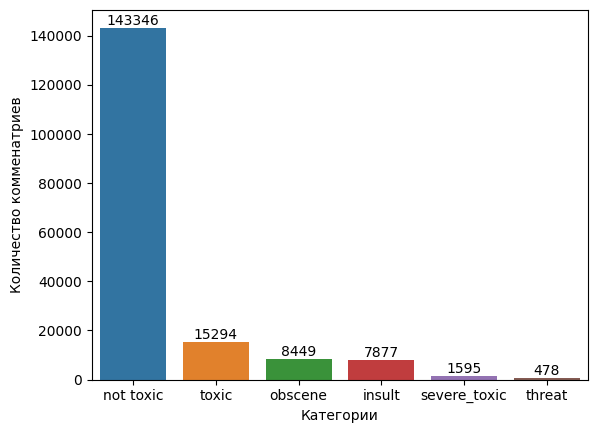

In [7]:
ax = sns.barplot(data=labels_count, x='Категории', y='Количество комменатриев')
ax.bar_label(ax.containers[0]);

## Task 2

In [8]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /Users/mark-
[nltk_data]     khubbatulin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/mark-
[nltk_data]     khubbatulin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
STOP_WORDS = set(stopwords.words("english"))

In [10]:
toxic.head(2)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
id,,,,,,,
0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0


In [11]:
%%time
toxic['comment_text'] = toxic['comment_text'].str.lower()
toxic['tokens'] = toxic.apply(lambda x: word_tokenize(x['comment_text']), axis=1)

CPU times: user 43.1 s, sys: 314 ms, total: 43.4 s
Wall time: 43.5 s


In [12]:
%%time
toxic['tokens'] = toxic.apply(lambda x : [w for w in x['tokens'] if w.isalpha()], axis=1)

CPU times: user 1.53 s, sys: 37.7 ms, total: 1.57 s
Wall time: 1.57 s


In [13]:
%%time
toxic['tokens'] = toxic.apply(lambda x : [w for w in x['tokens'] if w not in STOP_WORDS], axis=1)

CPU times: user 1.42 s, sys: 24 ms, total: 1.45 s
Wall time: 1.45 s


In [14]:
toxic.loc['000103f0d9cfb60f']['tokens']

['matches',
 'background',
 'colour',
 'seemingly',
 'stuck',
 'thanks',
 'talk',
 'january',
 'utc']

In [15]:
toxic['text'] = toxic.apply(lambda x: ' '.join(x['tokens']), axis=1)

## Task 3

In [16]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [17]:
toxic.head(2)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,tokens,text
id,,,,,,,,,
0000997932d777bf,explanation\nwhy the edits made under my usern...,0,0,0,0,0,0,"[explanation, edits, made, username, hardcore,...",explanation edits made username hardcore metal...
000103f0d9cfb60f,d'aww! he matches this background colour i'm s...,0,0,0,0,0,0,"[matches, background, colour, seemingly, stuck...",matches background colour seemingly stuck than...


In [18]:
train, test = train_test_split(toxic, random_state=21, test_size=0.3, shuffle=True)

In [19]:
CATEGORIES = ['toxic' ,'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [20]:
X_train = train.text
X_test = test.text
print(X_train.shape)
print(X_test.shape)

(111699,)
(47872,)


In [21]:
tf_idf = TfidfVectorizer(max_features=3000)

In [22]:
X_train_tf_idf = tf_idf.fit_transform(X_train)
X_test_tf_idf = tf_idf.transform(X_test)
y_train = train[CATEGORIES]
y_test = test[CATEGORIES]

In [23]:
X_train_tf_idf = pd.DataFrame(
    X_train_tf_idf.toarray(), columns=tf_idf.get_feature_names_out(), index=X_train.index)
X_test_tf_idf = pd.DataFrame(
    X_test_tf_idf.toarray(), columns=tf_idf.get_feature_names_out(), index=X_test.index
)

In [24]:
X_train_tf_idf.shape

(111699, 3000)

## Task 4

In [25]:
from sklearn.linear_model import RidgeClassifier

In [26]:
model = RidgeClassifier()
            
model.fit(X_train_tf_idf, y_train)
predictions = model.predict(X_test_tf_idf)


print('Accuracy = ', accuracy_score(y_test, predictions))
print('ROC-AUC score is ', roc_auc_score(y_test, predictions))

Accuracy =  0.915274064171123
ROC-AUC score is  0.6481721030491848


In [27]:
predictions

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]])

## Task 5

In [26]:
import re
import string

In [27]:
toxic.head(2)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,tokens,text
id,,,,,,,,,
0000997932d777bf,explanation\nwhy the edits made under my usern...,0,0,0,0,0,0,"[explanation, edits, made, username, hardcore,...",explanation edits made username hardcore metal...
000103f0d9cfb60f,d'aww! he matches this background colour i'm s...,0,0,0,0,0,0,"[matches, background, colour, seemingly, stuck...",matches background colour seemingly stuck than...


In [28]:
toxic['count_sent'] = toxic["comment_text"].apply(lambda x: len(re.findall("\n",str(x)))+1)
toxic['count_word'] = toxic["comment_text"].apply(lambda x: len(str(x).split()))
toxic['count_unique_word'] = toxic["comment_text"].apply(lambda x: len(set(str(x).split())))
toxic['count_letters'] = toxic["comment_text"].apply(lambda x: len(str(x)))
toxic["count_punctuations"] = toxic["comment_text"].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))
toxic["count_words_upper"] = toxic["comment_text"].apply(lambda x: len([w for w in str(x).split() if w.isupper()]))
toxic["count_words_title"] = toxic["comment_text"].apply(lambda x: len([w for w in str(x).split() if w.istitle()]))
toxic["count_stopwords"] = toxic["comment_text"].apply(lambda x: len([w for w in str(x).lower().split() if w in STOP_WORDS]))
toxic["mean_word_len"] = toxic["comment_text"].apply(lambda x: np.mean([len(w) for w in str(x).split()]))

In [29]:
train_2, test_2 = train_test_split(toxic.iloc[:, 9:], random_state=21, test_size=0.3, shuffle=True)

In [30]:
X_train_tf_idf

,ability,able,absolute,absolutely,absurd,abuse,abusing,abusive,academic,accept,...,yes,yesterday,yet,yo,york,youbollocks,young,yourselfgo,youtube,zero
id,,,,,,,,,,,,,,,,,,,,,
ad8940c5fd973822,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
a39b0a9278b40d49,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0aa921bf6b6f94a3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
fa7b15b9cb4dfcfd,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23125445855c60c6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
aad79cb6f6a7d543,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
db445b6d3a28fc46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ed5bff558e2e0cfa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
train_2

,count_sent,count_word,count_unique_word,count_letters,count_punctuations,count_words_upper,count_words_title,count_stopwords,mean_word_len
id,,,,,,,,,
ad8940c5fd973822,5,37,35,211,13,0,0,12,4.621622
a39b0a9278b40d49,7,140,95,835,22,0,0,63,4.942857
0aa921bf6b6f94a3,1,9,8,36,0,0,0,6,3.111111
fa7b15b9cb4dfcfd,3,42,36,240,6,0,0,21,4.642857
23125445855c60c6,2,27,24,158,6,0,0,11,4.851852
...,...,...,...,...,...,...,...,...,...
aad79cb6f6a7d543,1,26,24,155,6,0,0,13,5.000000
db445b6d3a28fc46,1,21,21,118,6,0,0,11,4.619048
ed5bff558e2e0cfa,1,7,7,43,8,0,0,3,5.285714


In [32]:
X_train_tf_idf

,ability,able,absolute,absolutely,absurd,abuse,abusing,abusive,academic,accept,...,yes,yesterday,yet,yo,york,youbollocks,young,yourselfgo,youtube,zero
id,,,,,,,,,,,,,,,,,,,,,
ad8940c5fd973822,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
a39b0a9278b40d49,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0aa921bf6b6f94a3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
fa7b15b9cb4dfcfd,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23125445855c60c6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
aad79cb6f6a7d543,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
db445b6d3a28fc46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ed5bff558e2e0cfa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
train_3 = train_2.join(X_train_tf_idf)
test_3 = test_2.join(X_test_tf_idf)

In [34]:
model = RidgeClassifier()
            
model.fit(train_3, y_train)
predictions = model.predict(test_3)


print('Accuracy = ', accuracy_score(y_test, predictions))
print('ROC-AUC score is ', roc_auc_score(y_test, predictions))

Accuracy =  0.9153576203208557
ROC-AUC score is  0.6500447496781735
